# TCN + Sliding Window + BiGRU + XGBoost — CMAPSS Failure Prediction

**Pipeline:**
1. Sliding window ile sekans oluşturma
2. TCN → dilated causal conv ile yerel/global temporal özellik
3. BiGRU → ileri + geri yönde zamansal bağımlılık
4. Attention pooling → sekans özeti
5. XGBoost → derin özellikler üzerinde nihai sınıflandırıcı

Tüm FD001-FD004 desteklenir; CFG'den dataset seçilir.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q xgboost

In [ ]:
import numpy as np
import pandas as pd
import os, warnings, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


## Konfigürasyon

In [ ]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # --- Veri ---
    'dataset'       : 'FD001',   # FD001 | FD002 | FD003 | FD004
    'rul_threshold' : 30,
    'seq_len'       : 40,        # sliding window uzunluğu
    'stride'        : 1,
    'val_engine_frac': 0.15,

    # --- TCN ---
    'tcn_channels'  : [64, 128, 128, 64],
    'tcn_kernel'    : 3,
    'tcn_dropout'   : 0.2,

    # --- BiGRU ---
    'gru_hidden'    : 128,       # tek yön hidden; çıkış 2x
    'gru_layers'    : 2,
    'gru_dropout'   : 0.3,

    # --- Embedding boyutu (projection) ---
    'embed_dim'     : 128,

    # --- Eğitim ---
    'epochs'        : 60,
    'batch_size'    : 256,
    'lr'            : 1e-3,
    'weight_decay'  : 1e-4,
    'patience'      : 12,
    'focal_gamma'   : 2.0,

    # --- XGBoost ---
    'xgb_rounds'    : 800,
    'xgb_lr'        : 0.03,
    'xgb_depth'     : 6,
    'xgb_subsample' : 0.8,
    'xgb_colsample' : 0.8,
    'xgb_min_child' : 5,
    'xgb_alpha'     : 0.1,
    'xgb_lambda'    : 1.0,
    'xgb_es_rounds' : 40,
}

## Veri Yükleme ve Ön İşleme

In [ ]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)

# Bilgi taşımayan sensörler (sıfır varyans veya sabit)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def get_features(df):
    drop = ['unit_number', 'time_in_cycles', 'RUL'] + DROP_SENSORS
    feat_cols = [c for c in df.columns if c not in drop]
    return feat_cols


def split_train_val(train_df, val_frac, seed=42):
    units = train_df['unit_number'].unique()
    rng   = np.random.RandomState(seed)
    val_units = rng.choice(units, size=int(len(units) * val_frac), replace=False)
    val_mask  = train_df['unit_number'].isin(val_units)
    return train_df[~val_mask].copy(), train_df[val_mask].copy()


def make_sliding_windows(df, feat_cols, seq_len, stride, threshold):
    """
    Her motor için sliding window sekansları oluşturur.
    Label: son adımın RUL < threshold ise 1 (yakın arıza), 0 değil.
    """
    X_list, y_list = [], []
    for uid, group in df.groupby('unit_number'):
        arr   = group[feat_cols].values.astype(np.float32)
        labels = (group['RUL'].values < threshold).astype(np.int64)
        T = len(arr)
        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(arr[start:end])         # (seq_len, n_feat)
            y_list.append(labels[end - 1])        # son adımın etiketi
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


def make_test_windows(test_df, rul_df, feat_cols, seq_len, threshold):
    """
    Test setinde her motor için son seq_len satırı alır.
    Gerçek label: son RUL < threshold.
    """
    X_list, y_list = [], []
    for idx, (uid, group) in enumerate(test_df.groupby('unit_number')):
        arr = group[feat_cols].values.astype(np.float32)
        # Dizinin son seq_len satırını al; kısa diziler için pad
        if len(arr) >= seq_len:
            window = arr[-seq_len:]
        else:
            pad    = np.zeros((seq_len - len(arr), arr.shape[1]), dtype=np.float32)
            window = np.vstack([pad, arr])
        true_rul = rul_df.iloc[idx]['RUL']
        label    = int(true_rul < threshold)
        X_list.append(window)
        y_list.append(label)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


# ── Yükleme ──
FD = CFG['dataset']
train_raw, test_raw, rul_raw = load_raw(FD)
train_raw = add_rul(train_raw)

# Train / Val bölme (motor bazlı — sızıntısız)
tr_df, val_df = split_train_val(train_raw, CFG['val_engine_frac'])

feat_cols = get_features(tr_df)
print(f'Feature sayısı: {len(feat_cols)}  |  Features: {feat_cols}')

# ── Ölçeklendirme (sadece train fit) ──
scaler = StandardScaler()
tr_df[feat_cols]  = scaler.fit_transform(tr_df[feat_cols])
val_df[feat_cols] = scaler.transform(val_df[feat_cols])
test_raw[feat_cols] = scaler.transform(test_raw[feat_cols])

# ── Sliding Window ──
SL, ST, TH = CFG['seq_len'], CFG['stride'], CFG['rul_threshold']

X_tr,  y_tr  = make_sliding_windows(tr_df,  feat_cols, SL, ST, TH)
X_val, y_val = make_sliding_windows(val_df, feat_cols, SL, ST, TH)
X_te,  y_te  = make_test_windows(test_raw, rul_raw, feat_cols, SL, TH)

print(f'Train: {X_tr.shape}  |  pos ratio: {y_tr.mean():.3f}')
print(f'Val  : {X_val.shape} |  pos ratio: {y_val.mean():.3f}')
print(f'Test : {X_te.shape}  |  pos ratio: {y_te.mean():.3f}')

Feature sayısı: 17  |  Features: ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train: (14254, 40, 17)  |  pos ratio: 0.179
Val  : (2477, 40, 17) |  pos ratio: 0.182
Test : (100, 40, 17)  |  pos ratio: 0.250


## Model: TCN + BiGRU + Attention

In [ ]:
# ────────────────────────────────────────────────
#  TCN Blok  (dilated causal conv + residual)
# ────────────────────────────────────────────────
class CausalConvBlock(nn.Module):
    """Tek dilated causal conv bloğu (WeightNorm + residual)."""
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation)
        )
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation)
        )
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        # x: (B, C, T)
        pad = self.conv1.weight.size(2) - 1  # bu sadece hesap, padding zaten uygulandı
        out = self.relu(self.conv1(x)[:, :, :x.size(2)])
        out = self.drop(out)
        out = self.relu(self.conv2(out)[:, :, :x.size(2)])
        out = self.drop(out)
        res = x if self.res is None else self.res(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """Dilated TCN — her katmanda dilation 2^i artar."""
    def __init__(self, in_ch, channels, kernel, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            layers.append(
                CausalConvBlock(in_ch, out_ch, kernel,
                                dilation=2**i, dropout=dropout)
            )
            in_ch = out_ch
        self.net    = nn.Sequential(*layers)
        self.out_ch = channels[-1]

    def forward(self, x):
        # x: (B, T, C_in)  →  (B, T, C_out)
        x = x.permute(0, 2, 1)   # → (B, C, T)
        x = self.net(x)
        return x.permute(0, 2, 1)  # → (B, T, C_out)


# ────────────────────────────────────────────────
#  Attention Pooling
# ────────────────────────────────────────────────
class AttentionPool(nn.Module):
    """Additive attention: sekansı tek vektöre sıkıştırır."""
    def __init__(self, hidden):
        super().__init__()
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (B, T, H)
        w = torch.softmax(self.fc(x), dim=1)   # (B, T, 1)
        return (w * x).sum(dim=1)               # (B, H)


# ────────────────────────────────────────────────
#  Ana Model: TCN → BiGRU → Attention → Projection
# ────────────────────────────────────────────────
class TCNBiGRU(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        # TCN
        self.tcn = TCN(
            in_ch    = n_feat,
            channels = cfg['tcn_channels'],
            kernel   = cfg['tcn_kernel'],
            dropout  = cfg['tcn_dropout'],
        )
        tcn_out = cfg['tcn_channels'][-1]

        # BiGRU
        self.bigru = nn.GRU(
            input_size  = tcn_out,
            hidden_size = cfg['gru_hidden'],
            num_layers  = cfg['gru_layers'],
            batch_first = True,
            bidirectional = True,
            dropout     = cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0,
        )
        gru_out = cfg['gru_hidden'] * 2   # bidirectional → 2x

        # Attention
        self.attn = AttentionPool(gru_out)

        # Projection → embedding
        self.proj = nn.Sequential(
            nn.Linear(gru_out, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        # Classifier head (binary)
        self.head = nn.Linear(cfg['embed_dim'], 1)

    def embed(self, x):
        """Sadece embedding döndür (XGBoost için)."""
        # x: (B, T, F)
        t   = self.tcn(x)           # (B, T, tcn_out)
        h,_ = self.bigru(t)         # (B, T, 2*gru_hidden)
        c   = self.attn(h)          # (B, 2*gru_hidden)
        return self.proj(c)         # (B, embed_dim)

    def forward(self, x):
        emb = self.embed(x)
        return self.head(emb).squeeze(-1)   # (B,)


n_feat = X_tr.shape[2]
model  = TCNBiGRU(n_feat, CFG).to(DEVICE)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametre sayısı: {total:,}')

Parametre sayısı: 722,690


## Focal Loss + Eğitim Döngüsü

In [ ]:
class FocalLoss(nn.Module):
    """Sınıf dengesizliğine karşı focal loss (BCE tabanlı)."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets.float(),
            pos_weight=self.pos_weight, reduction='none'
        )
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


def get_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)


# Sınıf ağırlığı
pos_w = torch.tensor([(y_tr == 0).sum() / (y_tr == 1).sum()],
                     dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(gamma=CFG['focal_gamma'], pos_weight=pos_w)
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5
)

tr_loader  = get_loader(X_tr,  y_tr,  CFG['batch_size'], shuffle=True)
val_loader = get_loader(X_val, y_val, CFG['batch_size'], shuffle=False)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, trues = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            trues.extend(yb.detach().cpu().numpy())
    preds, trues = np.array(preds), np.array(trues)
    avg_loss = total_loss / len(trues)
    f1  = f1_score(trues, (preds > 0.5).astype(int), zero_division=0)
    auc = roc_auc_score(trues, preds) if len(np.unique(trues)) > 1 else 0.5
    return avg_loss, f1, auc


print('Eğitim başlıyor...')
best_val_f1   = -1
best_state    = None
no_improve    = 0
history       = {'tr_loss':[], 'val_loss':[], 'tr_f1':[], 'val_f1':[], 'val_auc':[]}

for ep in range(1, CFG['epochs'] + 1):
    tr_loss, tr_f1, _       = run_epoch(tr_loader,  train=True)
    val_loss, val_f1, val_auc = run_epoch(val_loader, train=False)
    scheduler.step()

    history['tr_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['tr_f1'].append(tr_f1)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1

    if ep % 5 == 0 or ep == 1:
        print(f'Ep {ep:3d} | '
              f'tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | '
              f'val_loss={val_loss:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}')

    if no_improve >= CFG['patience']:
        print(f'Early stopping at epoch {ep}')
        break

model.load_state_dict(best_state)
print(f'\nEn iyi val F1: {best_val_f1:.4f}')

Eğitim başlıyor...
Ep   1 | tr_loss=0.1423 tr_f1=0.6992 | val_loss=0.0498 val_f1=0.8313 val_auc=0.9945
Ep   5 | tr_loss=0.0246 tr_f1=0.9330 | val_loss=0.0442 val_f1=0.9162 val_auc=0.9961
Ep  10 | tr_loss=0.0133 tr_f1=0.9712 | val_loss=0.0765 val_f1=0.8485 val_auc=0.9952
Ep  15 | tr_loss=0.0056 tr_f1=0.9849 | val_loss=0.1029 val_f1=0.8953 val_auc=0.9939
Early stopping at epoch 17

En iyi val F1: 0.9162


## Eğitim Grafikleri

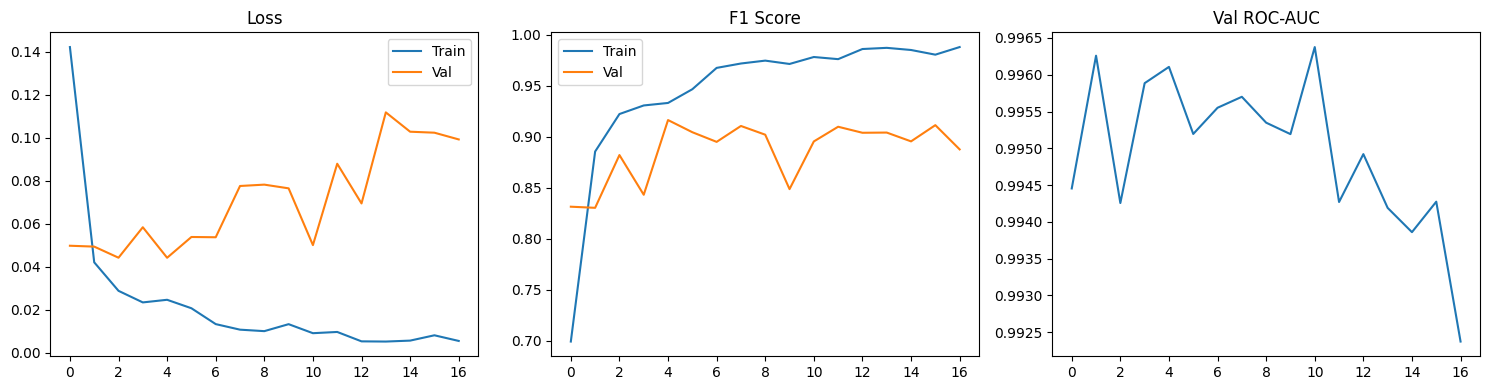

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['tr_loss'],  label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['tr_f1'],  label='Train')
axes[1].plot(history['val_f1'], label='Val')
axes[1].set_title('F1 Score'); axes[1].legend()

axes[2].plot(history['val_auc'])
axes[2].set_title('Val ROC-AUC')

plt.tight_layout()
plt.show()

## Embedding Çıkarımı (XGBoost için)

In [ ]:
@torch.no_grad()
def extract_embeddings(X_np, batch_size=512):
    """Numpy array → embedding numpy array."""
    model.eval()
    embs = []
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_np)),
        batch_size=batch_size, shuffle=False
    )
    for (xb,) in loader:
        embs.append(model.embed(xb.to(DEVICE)).detach().cpu().numpy())
    return np.vstack(embs)


print('Embedding çıkarılıyor...')
emb_tr  = extract_embeddings(X_tr)
emb_val = extract_embeddings(X_val)
emb_te  = extract_embeddings(X_te)

print(f'emb_tr  : {emb_tr.shape}')
print(f'emb_val : {emb_val.shape}')
print(f'emb_te  : {emb_te.shape}')

# Train + Val'ı XGBoost eğitimi için birleştir
emb_tr_full = np.vstack([emb_tr, emb_val])
y_tr_full   = np.concatenate([y_tr, y_val])

Embedding çıkarılıyor...
emb_tr  : (14254, 128)
emb_val : (2477, 128)
emb_te  : (100, 128)


## XGBoost Eğitimi

In [ ]:
scale_pos = (y_tr_full == 0).sum() / (y_tr_full == 1).sum()

dtrain = xgb.DMatrix(emb_tr_full, label=y_tr_full)
dval   = xgb.DMatrix(emb_val,     label=y_val)
dtest  = xgb.DMatrix(emb_te,      label=y_te)

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['logloss', 'auc'],
    'eta'              : CFG['xgb_lr'],
    'max_depth'        : CFG['xgb_depth'],
    'subsample'        : CFG['xgb_subsample'],
    'colsample_bytree' : CFG['xgb_colsample'],
    'min_child_weight' : CFG['xgb_min_child'],
    'reg_alpha'        : CFG['xgb_alpha'],
    'reg_lambda'       : CFG['xgb_lambda'],
    'scale_pos_weight' : scale_pos,
    'tree_method'      : 'hist',
    'seed'             : 42,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round   = CFG['xgb_rounds'],
    evals             = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = CFG['xgb_es_rounds'],
    evals_result      = evals_result,
    verbose_eval      = 50,
)
print(f'\nEn iyi round: {xgb_model.best_iteration}')

[0]	train-logloss:0.66441	train-auc:0.99775	val-logloss:0.66517	val-auc:0.99078
[50]	train-logloss:0.12898	train-auc:0.99969	val-logloss:0.14638	val-auc:0.99846
[100]	train-logloss:0.04077	train-auc:0.99983	val-logloss:0.06108	val-auc:0.99893
[150]	train-logloss:0.02161	train-auc:0.99986	val-logloss:0.04211	val-auc:0.99908
[200]	train-logloss:0.01619	train-auc:0.99989	val-logloss:0.03537	val-auc:0.99925
[250]	train-logloss:0.01357	train-auc:0.99991	val-logloss:0.03092	val-auc:0.99940
[300]	train-logloss:0.01152	train-auc:0.99994	val-logloss:0.02651	val-auc:0.99957
[350]	train-logloss:0.00993	train-auc:0.99996	val-logloss:0.02303	val-auc:0.99973
[400]	train-logloss:0.00867	train-auc:0.99997	val-logloss:0.02027	val-auc:0.99980
[450]	train-logloss:0.00763	train-auc:0.99998	val-logloss:0.01773	val-auc:0.99985
[500]	train-logloss:0.00685	train-auc:0.99999	val-logloss:0.01591	val-auc:0.99988
[550]	train-logloss:0.00620	train-auc:0.99999	val-logloss:0.01426	val-auc:0.99990
[600]	train-logloss

## Eşik Optimizasyonu (F1 max)

In [ ]:
val_probs = xgb_model.predict(dval)

best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_val, (val_probs > thr).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f'En iyi eşik: {best_thr:.2f}  |  Val F1: {best_f1:.4f}')

En iyi eşik: 0.74  |  Val F1: 0.9989


## Test Seti Değerlendirme

In [ ]:
test_probs = xgb_model.predict(dtest)
test_preds = (test_probs > best_thr).astype(int)

f1   = f1_score(y_te, test_preds, zero_division=0)
auc  = roc_auc_score(y_te, test_probs)
ap   = average_precision_score(y_te, test_probs)

print('=' * 50)
print(f'  Test F1 Score  : {f1:.4f}')
print(f'  Test ROC-AUC   : {auc:.4f}')
print(f'  Test Avg Prec  : {ap:.4f}')
print('=' * 50)
print()
print(classification_report(y_te, test_preds,
                             target_names=['Normal', 'Yakın Arıza']))

  Test F1 Score  : 0.8696
  Test ROC-AUC   : 0.9952
  Test Avg Prec  : 0.9862

              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96        75
 Yakın Arıza       0.95      0.80      0.87        25

    accuracy                           0.94       100
   macro avg       0.94      0.89      0.92       100
weighted avg       0.94      0.94      0.94       100



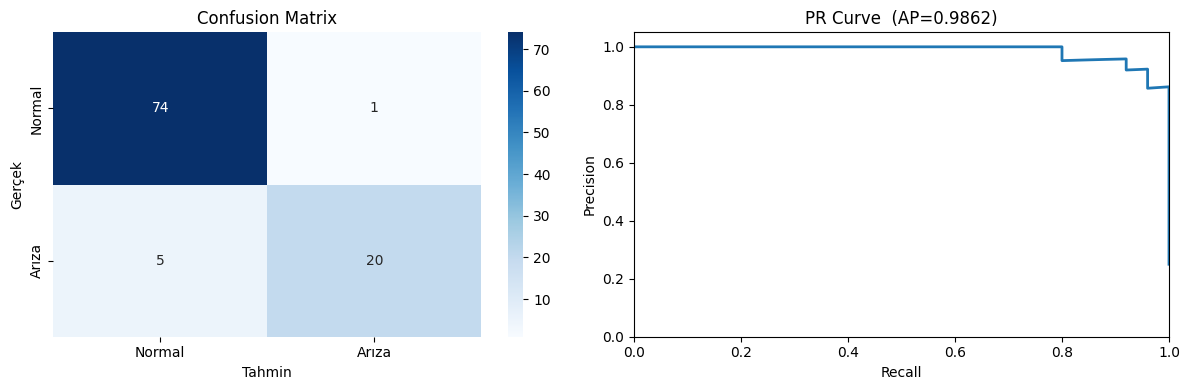

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_te, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Arıza'], yticklabels=['Normal','Arıza'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Tahmin'); axes[0].set_ylabel('Gerçek')

# PR Curve
prec, rec, _ = precision_recall_curve(y_te, test_probs)
axes[1].plot(rec, prec, lw=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve  (AP={ap:.4f})')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## Tüm FD001-FD004 Toplu Değerlendirme

In [ ]:
def run_full_pipeline(fd, cfg=CFG):
    """Verilen FD için tüm pipeline'ı çalıştırır ve metrikleri döndürür."""
    seed_everything(42)

    # Veri
    train_r, test_r, rul_r = load_raw(fd)
    train_r = add_rul(train_r)
    tr, va  = split_train_val(train_r, cfg['val_engine_frac'])
    fc      = get_features(tr)

    sc = StandardScaler()
    tr[fc]  = sc.fit_transform(tr[fc])
    va[fc]  = sc.transform(va[fc])
    test_r[fc] = sc.transform(test_r[fc])

    SL, ST, TH = cfg['seq_len'], cfg['stride'], cfg['rul_threshold']
    Xtr, ytr   = make_sliding_windows(tr, fc, SL, ST, TH)
    Xva, yva   = make_sliding_windows(va, fc, SL, ST, TH)
    Xte, yte   = make_test_windows(test_r, rul_r, fc, SL, TH)

    # Model
    m = TCNBiGRU(Xtr.shape[2], cfg).to(DEVICE)
    pw = torch.tensor([(ytr==0).sum()/(ytr==1).sum()], dtype=torch.float32).to(DEVICE)
    crit = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pw)
    opt  = torch.optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'], eta_min=1e-5)

    trl = get_loader(Xtr, ytr, cfg['batch_size'])
    val_loader_fd = get_loader(Xva, yva, cfg['batch_size'], shuffle=False)

    best_f1, best_st, no_imp = -1, None, 0
    for ep in range(1, cfg['epochs'] + 1):
        # train
        m.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(m(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
        # val
        m.eval()
        vp, vt = [], []
        with torch.no_grad():
            for xb, yb in val_loader_fd:
                vp.extend(torch.sigmoid(m(xb.to(DEVICE))).detach().cpu().numpy())
                vt.extend(yb.detach().cpu().numpy())
        vf1 = f1_score(vt, (np.array(vp)>0.5).astype(int), zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_st = {k: v.cpu().clone() for k,v in m.state_dict().items()}
            no_imp  = 0
        else:
            no_imp += 1
        if no_imp >= cfg['patience']:
            break

    m.load_state_dict(best_st)

    # Embedding
    @torch.no_grad()
    def _emb(X):
        m.eval()
        parts = []
        for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=512):
            parts.append(m.embed(xb.to(DEVICE)).detach().cpu().numpy())
        return np.vstack(parts)

    etr = np.vstack([_emb(Xtr), _emb(Xva)])
    ytr_f = np.concatenate([ytr, yva])
    ete  = _emb(Xte)
    eva  = _emb(Xva)

    sp  = (ytr_f==0).sum() / (ytr_f==1).sum()
    xm  = xgb.train(
        {**{'objective':'binary:logistic','eval_metric':['logloss','auc'],
            'eta':cfg['xgb_lr'],'max_depth':cfg['xgb_depth'],
            'subsample':cfg['xgb_subsample'],'colsample_bytree':cfg['xgb_colsample'],
            'min_child_weight':cfg['xgb_min_child'],'reg_alpha':cfg['xgb_alpha'],
            'reg_lambda':cfg['xgb_lambda'],'scale_pos_weight':sp,
            'tree_method':'hist','seed':42}},
        xgb.DMatrix(etr, label=ytr_f),
        num_boost_round=cfg['xgb_rounds'],
        evals=[(xgb.DMatrix(eva, label=yva), 'val')],
        early_stopping_rounds=cfg['xgb_es_rounds'],
        verbose_eval=False,
    )

    vp2 = xm.predict(xgb.DMatrix(eva))
    best_thr2, best_f1_2 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.01):
        f = f1_score(yva, (vp2>t).astype(int), zero_division=0)
        if f > best_f1_2:
            best_f1_2, best_thr2 = f, t

    tp = xm.predict(xgb.DMatrix(ete))
    preds = (tp > best_thr2).astype(int)
    return {
        'F1'   : f1_score(yte, preds, zero_division=0),
        'AUC'  : roc_auc_score(yte, tp) if len(np.unique(yte))>1 else np.nan,
        'AP'   : average_precision_score(yte, tp),
    }


print('Tüm dataset\'lar çalıştırılıyor...')
results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f'  {fd}...', end=' ', flush=True)
    r = run_full_pipeline(fd)
    results[fd] = r
    print(f"F1={r['F1']:.4f}  AUC={r['AUC']:.4f}  AP={r['AP']:.4f}")

df_res = pd.DataFrame(results).T
df_res.loc['Mean'] = df_res.mean()
print('\n', df_res.round(4))

Tüm dataset'lar çalıştırılıyor...
  FD001... F1=0.8889  AUC=0.9941  AP=0.9826
  FD002... F1=0.9440  AUC=0.9986  AP=0.9955
  FD003... F1=0.9000  AUC=0.9962  AP=0.9853
  FD004... F1=0.8411  AUC=0.9785  AP=0.9111

            F1     AUC      AP
FD001  0.8889  0.9941  0.9826
FD002  0.9440  0.9986  0.9955
FD003  0.9000  0.9962  0.9853
FD004  0.8411  0.9785  0.9111
Mean   0.8935  0.9919  0.9686


## Model Kaydetme

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/tcn_bigru_{FD}.pt')
xgb_model.save_model(f'{SAVE_DIR}/xgb_{FD}.ubj')
print('Modeller kaydedildi.')

Modeller kaydedildi.
